# Kuramoto Universe — Hierarchical Plastic Oscillator Fluid

## What this is and why it exists

This notebook is the third in a sequence:

1. **kuramoto_ring.ipynb** — A 1D nearest-neighbour Kuramoto ring. Establishes the basic
   physics: winding number selection, local coherence, phase slips, the lock-drift boundary
   K·R_eff = |Δ| as a diagnostic heuristic. Peer-reviewed by Opus and GPT. Ships clean.

2. **meteorology.ipynb** — Six simulations on the same mathematical substrate. The central
   result: a ring with *structured* spatial frequency disorder shows 62% boundary count
   reduction over T=200 (domain coarsening). A Gaussian control shows only 10% reduction.
   Coarsening is structure-dependent, not generic.

3. **This notebook** — The next step. What if the oscillators themselves could move, and
   their spatial topology could evolve in response to their phase dynamics?

---

## The core idea (from Grok + Gemini, 2026-05-17)

Two frontier AI models were given both notebooks and the Threshold of Harmony image — no
priming on theory. Both independently arrived at the same synthesis:

> **The harmony threshold (K·R_eff = |Δ|) is not just a diagnostic. It is a universal
> operator. It is the precise boundary where isolated, detuned oscillators stop being
> individuals and become the chain.**

Grok's formulation: *"Woo, but the code runs."*

The key insight: **synchronisation under scarcity creates structure.** Without a conservation
law, the Hebbian rule densifies everything uniformly (see meteorology.ipynb cells 4–5 — no
scale-free topology emerges). Add a connection budget constraint AND dissipation (lambda
decay) AND mobility, and the system is forced to select.

---

## Architecture decisions

### Why cells (rings of oscillators) rather than individual oscillators?

Because we want two scales of dynamics simultaneously:
- Internal ring: fast, local phase coupling (intra-cell Kuramoto)
- External coupling: slow, plastic, via macroscopic order parameters Z_i = R_i·e^{iΦ_i}

This is the correct biological/cosmological analogy. Neurons fire in local assemblies.
Galaxy clusters interact via their mass centres, not individual stars.

### Why conserved Hebbian with lambda decay?

The three-ingredient theorem from meteorology.ipynb: you need kinematics + feedback +
**dissipation**. Without dissipation (lambda decay), the W matrix converges to uniform
saturation. With it, connections that aren't reinforced by phase alignment decay away,
allowing the network to select for structure.

### Why phase-degeneracy pressure instead of standard repulsion?

Gemini's key insight: if repulsion scales with phase similarity (fully locked cells repel
maximally; out-of-phase cells pass through each other), then:

- Locked clusters can't overlap spatially
- But they're bound together by Hebbian weights
- So they're **forced to extrude into lower-dimensional structures: lines, sheets, filaments**

"The network topology literally extrudes the spatial geometry."

The same three ingredients appear in cosmic web formation — though this notebook demonstrates the analogy at toy-model scale, not as a proof. In this toy model, phase-dependent repulsion plus conserved Hebbian attraction favours extended sparse structures rather than compact collapse.

---

## What to look for

**Milestone 1 (t ≈ 200-500):** Global R should oscillate between 0.5 and 0.9. Mean local
R should stabilise around 0.85-0.92. The system has found its dynamic equilibrium.

**Milestone 2 (t ≈ 500-1000):** Cells should begin forming chains. Look for elongated
clusters in the scatter plot — size = R, colour = phase (hsv). Anomaly cells (seeded with
+2.5 frequency boost) should sit at the joints or heads of filaments.

**Milestone 3 (t ≈ 1000+):** Filamentary structure with voids. If you see chains of 8–20
locked cells snaking through 2D space with drifting cells occupying the voids, the
phase-degeneracy pressure mechanism is working.

**After milestone 3:** Flip `USE_OMEGA_PLASTICITY = True`. The anomaly cells become
self-tuning agents that navigate the lock-drift boundary. Watch for persistent, self-propelled
"anomaly objects" that crawl along filaments — the cosmic web jets / atmospheric blocking
highs analogue.

---

## Connection to the broader theory

- [[witness-theory]]: The observer becomes the gradient. The chain IS the self-modelling loop.
  A locked cluster that observes its own phase coherence is a minimal witness.
- OPH (observer-patch holography): "Anomaly objects that navigate the threshold without dying
  into full coherence or dissolving into noise" maps onto what OPH says about observer
  patches maintaining coherence at the boundary.
- NWM interpretability (external work): Transformer attention heads in FourCastNet should show
  chimera-like structure — some globally coherent (planetary scale), others fragmented
  (mesoscale). The boundary = forecast skill degradation. This notebook is the physical model
  for what those attention heads are doing.

---

## Companion notebooks

- `kuramoto_ring.ipynb` — 1D ring physics, winding number diagnostics
- `meteorology.ipynb` — Structured vs Gaussian coarsening, Hebbian negative result

All three notebooks live in `/home/ben/src/`. Not yet pushed to flywheel-universe repo —
holding until external physics feedback settles.

---

## Run Log — Parameter Evolution & Results

| Run | Omega Plasticity | eta_omega | K_inter | budget | repulse_k | lam_decay | Active Edges | Mean Degree | Key Outcome |
|-----|------------------|-----------|---------|--------|-----------|-----------|--------------|-------------|-------------|
| 8   | OFF              | -         | 0.4     | 1.5    | 6.0       | 0.003     | 164          | 3.4         | First clear filamentary web (mean edge ~11, 0 isolates) |
| 9   | ON               | 0.0025    | 0.4     | 1.5    | 6.0       | 0.003     | 189          | 3.9         | Boundary riders confirmed (3 persistent low-R anomalies, cell 86 degree-4/5 junction (varies by run)) |
| 10  | ON               | 0.003     | 0.4     | 1.5    | 6.0       | 0.003     | 216         | 4.5        | Sustained over T=5000, H1 loops in persistence homology, 4 riders actively sculpt web |

**Notes:**
- `exist_mask` Hebbian update enabled from Run 8 onward — the critical fix preventing budget diffusion.
- All runs: `K_intra=3.5`, `mobility=0.18`, anomaly boost `+2.5` on 12% of cells.
- Global R oscillates consistently in the **0.6–0.8 band** — the system lives dynamically at the harmony threshold.
- Full state (thetas, omegas, W, positions) can be saved for exact reproducibility.

---

## Key Implementation Choices

1. **`exist_mask` in `hebbian_update`** — Only updates existing connections. Without this, the budget diffuses uniformly across all N² pairs and all weights converge to near-zero. This single boolean mask is the most important line in the notebook.

2. **Phase-degeneracy repulsion** (Gemini) — Repulsion scales with phase similarity. Perfectly locked cells have maximum hard-sphere repulsion; out-of-phase cells pass through each other. This is what forces the locked clusters to extrude into filaments rather than collapsing into spheres.

3. **Staggered update schedule** — Macro order parameters every 5 steps, Hebbian every 10, mobility every 20. Prevents expensive recomputation at every step while keeping the dynamics correctly coupled.

4. **Lambda decay** (`lam_decay=0.003`) — The dissipation ingredient. Without it, all connections saturate uniformly. With it, connections not reinforced by phase alignment decay away, allowing the network to select for structure.



> **Note:** Because `exist_mask` restricts Hebbian updates to existing connections, the final graph is a pruned/reweighted subgraph of the initial kNN support — not unconstrained de novo topology formation. The initial kNN now uses torus minimum-image distance for consistency.


## 1. Parameters

## Design rationale for key parameters

- **M=96 cells, N=12 oscillators/cell**: 1,152 total oscillators. Manageable for Colab.
  Increase M to 256+ and N to 32+ for publication-quality runs (needs GPU).
- **K_intra=3.5**: Strong internal coupling ensures each cell is internally coherent before
  it starts coupling externally. Think of it as "the cell already knows what it is."
- **K_inter=0.4**: Weaker than K_intra — inter-cell coupling is the interesting dynamics.
  Too high and everything locks globally; too low and cells ignore each other.
- **budget=1.5**: Each cell has 1.5 total outgoing coupling to distribute. This is the
  scarcity constraint that forces selection.
- **lam_decay=0.003**: Lambda decay rate. This is the dissipation ingredient. Without it,
  W converges to uniform saturation (all cells equally connected = no structure).
- **USE_OMEGA_PLASTICITY=True (run 10)**: Start with static anomalies. Once filaments form, set
  this to True to watch anomaly cells become self-propelled agents.


In [1]:
# ═══════════════════════════════════════════════════════════════════════
# WORKFLOW: DO NOT MANUALLY EDIT THIS NOTEBOOK IN COLAB
# ───────────────────────────────────────────────────────────────────────
# 1. Agent edits parameters in /home/ben/src/kuramoto_universe.ipynb
# 2. You download that file to Colab (File → Upload)
# 3. Run all cells in Colab (Runtime → Restart and Run All)
# 4. Save Colab output (File → Download → .ipynb)
# 5. Copy downloaded file to /home/ben/src/kuramoto_universe.ipynb
#    (overwrite — src is the single source of truth)
# 6. Tell agent. Agent reads the results and patches next run.
#
# CURRENT RUN PARAMETERS (Run 10):
#   K_intra=3.5, K_inter=0.4, budget=1.5, repulse_k=6.0
#   anomaly: 12% of cells, +2.5 boost
#   omega_plasticity: ON (eta_omega=0.003)
#   lam_decay=0.003, spatial_decay=L*0.8
#   hebbian: only updates existing connections (key fix — was diffusing budget across all N² pairs)
#   mobility=0.18
#   T=5000, eta_omega=0.003
#   Target: watch boundary riders crawl, persistence homology on high-R cells
# ═══════════════════════════════════════════════════════════════════════

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

rng = np.random.default_rng(42)

# ── Cell / ring parameters ────────────────────────────────────────────────────
M = 96           # number of cells (particles)
N = 12           # oscillators per 1D ring cell
L = 30.0         # periodic 2D domain size

# ── Coupling strengths ────────────────────────────────────────────────────────
K_intra = 3.5   # lowered: makes cells "squishy" (local R ~0.75), can bridge phase clusters    # strong internal ring coupling
K_inter = 0.4   # nudged up from 0.3: restore dynamics while keeping sparse topology    # inter-cell coupling via order parameters
K_grav  = 0.08   # weak global gravitational pull (global order parameter term)

# ── Plasticity ────────────────────────────────────────────────────────────────
budget    = 1.5   # halved: each cell can only afford 2-3 strong connections → chain topology   # conserved total outgoing coupling per cell
eta_hebb  = 0.04  # Hebbian learning rate
lam_decay = 0.003  # reduced: 0.012 and 0.008 both killed all connections. decay must be < hebbian rate
knn_init  = 6     # initial k-nearest neighbours for W

# ── Mobility ──────────────────────────────────────────────────────────────────
mobility  = 0.18  # increased: anomalies move more freely (Grok recommendation)
repulse_r = 1.2   # short-range repulsion radius
repulse_k = 6.0   # tripled: asymptotic repulsion — phase-locked pairs violently repel → filaments   # repulsion strength

# ── Omega plasticity (turn on AFTER filaments appear) ────────────────────────
USE_OMEGA_PLASTICITY = True
USE_PERTURBATION  = False  # set True to ramp cell 86 to full lock at t=2500    # KEY: turns anomaly cells from static defects into active filament-sculpting agents
eta_omega = 0.003   # Run 10: slightly faster — clearer boundary-riding motion

# ── Integration ───────────────────────────────────────────────────────────────
dt          = 0.01
T_total     = 5000  # extended for run 10: watch anomalies crawl over longer time
steps       = int(T_total / dt)

# ── Update schedule (staggered for efficiency) ────────────────────────────────
MACRO_EVERY    = 5   # recompute R, phi, dtheta_ext
HEBBIAN_EVERY  = 10  # update W
MOBILITY_EVERY = 20  # update positions

print(f"M={M} cells × N={N} oscillators = {M*N} total oscillators")
print(f"T={T_total}, dt={dt}, steps={steps}")


M=96 cells × N=12 oscillators = 1152 total oscillators
T=5000, dt=0.01, steps=500000


## 2. Initialisation

## Initialisation rationale

**Hierarchical anomaly seeding:** 12% of cells get a +2.5 frequency boost. These are the
"jets" — regions that refuse full lock-in and organise everything around them. In the
meteorology analogy, these are the frequency-anomaly bands. In the cosmic web analogy,
these are the proto-filament seeds.

**kNN initialisation of W:** Starting with local connections (k=6 nearest neighbours)
rather than all-to-all. This mirrors biological and physical reality — local interactions
dominate. The Hebbian rule will then sculpt long-range connections as cells synchronise.

**Conservation from step 0:** The budget constraint is applied immediately after initialisation.
Each cell starts with exactly `budget=1.5` outgoing coupling, distributed across its
6 nearest neighbours.


In [2]:
# ── Helper: torus minimum-image distance (needed before initialisation) ───────
import numpy as np

def torus_dist_matrix(pos, L):
    """Minimum-image distance matrix on a periodic torus."""
    diff = pos[:, None, :] - pos[None, :, :]
    diff = diff - L * np.round(diff / L)
    return np.linalg.norm(diff, axis=-1)


In [3]:
# ── Phase and frequency fields ───────────────────────────────────────────────
thetas = rng.uniform(0, 2*np.pi, (M, N))
omegas = rng.normal(0.0, 0.65, (M, N))

# Hierarchical anomaly seeding: 12.5% of cells get a frequency boost (+2.5 boost)
n_anomaly = M // 8  # fewer anomalies: 12% instead of 20%
anomaly_idx = rng.choice(M, size=n_anomaly, replace=False)
omegas[anomaly_idx] += 2.5  # stronger jets: resist global phase lock more aggressively
print(f"Anomaly cells: {n_anomaly}/{M} seeded with +2.5 frequency boost")

# ── Spatial positions ─────────────────────────────────────────────────────────
positions = rng.uniform(0, L, (M, 2))

# ── Connectivity matrix (kNN initialisation, conserved budget) ───────────────
# Use torus minimum-image distance for initial kNN (consistent with Hebbian)
dists = torus_dist_matrix(positions, L)
np.fill_diagonal(dists, np.inf)
knn = np.argsort(dists, axis=1)[:, :knn_init]

W = np.zeros((M, M))
for i in range(M):
    W[i, knn[i]] = 1.0 + 0.1 * rng.standard_normal(knn_init)
    W[i, i] = 0.0
W = np.clip(W, 0, None)
row_sums = W.sum(axis=1, keepdims=True)
W = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums > 0) * budget

print(f"W initialised: mean non-zero weight = {W[W>0].mean():.3f}")
print(f"Row sums: min={W.sum(axis=1).min():.3f}, max={W.sum(axis=1).max():.3f}")


Anomaly cells: 12/96 seeded with +2.5 frequency boost
W initialised: mean non-zero weight = 0.250
Row sums: min=1.500, max=1.500


## 3. Core Functions

In [4]:
def compute_order_params(thetas):
    """Per-cell complex order parameter Z_i = R_i * exp(i*Phi_i)."""
    z = np.mean(np.exp(1j * thetas), axis=1)  # (M,)
    return z, np.abs(z), np.angle(z)

def intra_rhs(thetas, omegas):
    """Internal ring Kuramoto dynamics for all cells simultaneously."""
    return (omegas +
            K_intra * (np.sin(np.roll(thetas, -1, axis=1) - thetas) +
                       np.sin(np.roll(thetas,  1, axis=1) - thetas)))

def inter_drive(thetas, W, R_cells, phi_cells):
    """External coupling: macroscopic pull from other cells via W."""
    # drive[i, n] = K_inter * sum_j W[i,j] * R_j * sin(Phi_j - theta[i,n])
    # Vectorised: (M,M) × (M,N) broadcast
    rw = (W * R_cells[None, :])  # (M, M): W[i,j] * R_j
    phi_diff = phi_cells[None, :] - thetas[:, :, None]  # (M, N, M) -- expensive
    # Cheaper: for each cell i, sin(Phi_j - theta_im) summed over j
    drive = np.zeros_like(thetas)
    for i in range(M):
        if W[i].sum() > 1e-6:
            drive[i] = K_inter * np.sum(
                W[i, :, None] * R_cells[:, None] *
                np.sin(phi_cells[:, None] - thetas[i, None, :]),
                axis=0
            )
    return drive

def global_grav(thetas, z_cells):
    """Weak global mean-field gravitational pull."""
    z_global = np.mean(z_cells)
    R_global = np.abs(z_global)
    phi_global = np.angle(z_global)
    return K_grav * R_global * np.sin(phi_global - thetas)

def hebbian_update(W, R_cells, phi_cells, dists):
    """R-weighted Hebbian update with lambda decay and conserved budget."""
    C = np.cos(phi_cells[:, None] - phi_cells[None, :]) * R_cells[:, None] * R_cells[None, :]
    spatial = np.exp(-dists / (L * 0.8))  # spatial decay kernel
    np.fill_diagonal(spatial, 0)
    # KEY FIX: only update existing connections — prevents budget diffusion across all N² pairs
    exist_mask = (W > 1e-6).astype(float)
    W_new = W + eta_hebb * exist_mask * (C * spatial - lam_decay * W)
    W_new = np.clip(W_new, 0, None)
    np.fill_diagonal(W_new, 0)
    row_sums = W_new.sum(axis=1, keepdims=True)
    W_new = np.divide(W_new, row_sums, out=np.zeros_like(W_new), where=row_sums > 0) * budget
    return W_new

def phase_degeneracy_repulsion(positions, phi_cells):
    """Gemini's key idea: repulsion scales with phase similarity.
    Fully phase-locked pairs have maximum hard-sphere repulsion.
    Fully out-of-phase pairs pass through each other.
    """
    force = np.zeros_like(positions)
    for i in range(M):
        diff = positions[i] - positions  # (M, 2)
        diff = diff - L * np.round(diff / L)  # periodic wrapping
        r = np.linalg.norm(diff, axis=1)     # (M,)
        r[i] = np.inf  # no self-force
        mask = (r < repulse_r) & (r > 1e-6)
        if mask.any():
            phase_sim = np.cos(phi_cells[i] - phi_cells)  # 1=same phase, -1=opposite
            # Repulsion strength scales with phase similarity
            repulse_strength = repulse_k * np.maximum(0, phase_sim[mask]) / (r[mask]**2)
            force[i] = np.sum(repulse_strength[:, None] * diff[mask] / r[mask, None], axis=0)
    return force

def mobility_update(positions, R_cells, phi_cells, W):
    """Drift: anomalous cells (low R) move; add attraction and repulsion."""
    local_detuning = 1.0 - R_cells  # high detuning = drifting cell
    # Attraction toward synchronised neighbours (weighted by W)
    attract = np.zeros_like(positions)
    for i in range(M):
        j_mask = W[i] > 0.05
        if j_mask.any():
            delta = positions[j_mask] - positions[i]
            delta = delta - L * np.round(delta / L)
            attract[i] = mobility * np.sum(W[i, j_mask, None] * delta, axis=0) / budget

    # Phase-degeneracy repulsion (Gemini's idea)
    repulse = phase_degeneracy_repulsion(positions, phi_cells)

    positions_new = positions + attract + repulse
    positions_new %= L  # periodic boundary
    return positions_new


## 4. Main Integration Loop

In [5]:
# Snapshot storage for visualisation
history_R = []
history_pos = []
history_phi = []
history_W = []        # store W at each snapshot for honest evolution plot
history_R_cells = []  # store R_cells at each snapshot
history_anomaly_R = []   # track boundary rider R over time
snapshot_times = []
SNAPSHOT_EVERY = 100

z_cells, R_cells, phi_cells = compute_order_params(thetas)
dtheta_ext = inter_drive(thetas, W, R_cells, phi_cells)

print("Starting integration...")
for step in range(steps):
    t = step * dt

    # ── Phase integration (Euler, every step) ───────────────────────
    dtheta_int = intra_rhs(thetas, omegas)
    dtheta_g   = global_grav(thetas, z_cells)
    dthetas    = dtheta_int + dtheta_ext + dtheta_g
    thetas     = (thetas + dt * dthetas) % (2 * np.pi)

    # ── Macro update (every MACRO_EVERY steps) ──────────────────────
    if step % MACRO_EVERY == 0:
        z_cells, R_cells, phi_cells = compute_order_params(thetas)
        dtheta_ext = inter_drive(thetas, W, R_cells, phi_cells)

    # ── Hebbian plasticity (every HEBBIAN_EVERY steps) ──────────────
    if step % HEBBIAN_EVERY == 0:
        dists_now = torus_dist_matrix(positions, L)  # minimum-image distance (periodic)
        np.fill_diagonal(dists_now, np.inf)
        W = hebbian_update(W, R_cells, phi_cells, dists_now)

    # ── Mobility (every MOBILITY_EVERY steps) ───────────────────────
    if step % MOBILITY_EVERY == 0:
        positions = mobility_update(positions, R_cells, phi_cells, W)

    # ── Perturbation experiment (USE_PERTURBATION = True to run) ────────
    # Ramp cell 86's internal coupling to 50x over 100 steps, then hold.
    # This smoothly drives cell 86 toward full lock without a numerical shock.
    # The ramp is applied BEFORE thetas update for that step (not stale).
    # TODO: cell 86 currently receives BOTH normal integration and perturbation.
    # The comment says "skip normal update" but the code adds on top.
    # Fix before running USE_PERTURBATION=True — this does not affect current (False) results.
    if USE_PERTURBATION:
        t_perturb = int(0.5 * steps)
        if step == t_perturb:
            print(f"PERTURBATION: cell 86 ramp starting at t={step*dt:.0f}")
        if t_perturb <= step <= t_perturb + 100:
            ramp_progress = (step - t_perturb) / 100.0
            K86 = K_intra * (1.0 + 49.0 * ramp_progress)  # ramps 1x → 50x
            dtheta86 = K86 * (np.sin(np.roll(thetas[86], -1) - thetas[86]) +
                               np.sin(np.roll(thetas[86],  1) - thetas[86]))
            thetas[86] = thetas[86] + dt * (omegas[86] + dtheta86)
            thetas[86] = thetas[86] % (2 * np.pi)  # wrap, skip the normal update for cell 86

    # ── Omega plasticity (optional — turn on after filaments appear) ─
    if USE_OMEGA_PLASTICITY:
        experienced = dthetas - omegas
        omegas += eta_omega * experienced
        omegas -= omegas.mean()  # conserve global mean frequency

    # ── Snapshots ───────────────────────────────────────────────────
    if step % SNAPSHOT_EVERY == 0:
        global_R = float(np.abs(np.mean(z_cells)))
        history_R.append(global_R)
        history_pos.append(positions.copy())
        history_phi.append(phi_cells.copy())
        history_W.append(W.copy())
        history_R_cells.append(R_cells.copy())
        history_anomaly_R.append(R_cells[anomaly_idx].copy())
        snapshot_times.append(t)
        if step % 5000 == 0:
            print(f"t={t:.0f}: global R={global_R:.3f}, mean local R={R_cells.mean():.3f}")

print("Integration complete.")


Starting integration...
t=0: global R=0.015, mean local R=0.273
t=50: global R=0.624, mean local R=0.767
t=100: global R=0.710, mean local R=0.770
t=150: global R=0.729, mean local R=0.771
t=200: global R=0.705, mean local R=0.771
t=250: global R=0.743, mean local R=0.771
t=300: global R=0.725, mean local R=0.771
t=350: global R=0.755, mean local R=0.771
t=400: global R=0.764, mean local R=0.771
t=450: global R=0.751, mean local R=0.770
t=500: global R=0.742, mean local R=0.771
t=550: global R=0.744, mean local R=0.770
t=600: global R=0.720, mean local R=0.771
t=650: global R=0.752, mean local R=0.770
t=700: global R=0.762, mean local R=0.771
t=750: global R=0.737, mean local R=0.771
t=800: global R=0.735, mean local R=0.771
t=850: global R=0.733, mean local R=0.770
t=900: global R=0.724, mean local R=0.771
t=950: global R=0.769, mean local R=0.771
t=1000: global R=0.709, mean local R=0.770
t=1050: global R=0.750, mean local R=0.770
t=1100: global R=0.748, mean local R=0.771
t=1150: gl

## 1.5 Perturbation Experiment (future work — not part of signed-off result) (experimental stub — not yet validated)

> **Status:** The perturbation code in cell 11 has a known double-update issue (see TODO comment). Set USE_PERTURBATION=True to explore, but treat results as qualitative until the code is fixed.

**Question:** Cell 86 is the only junction holding four or five filaments (varies by run) together at partial coherence (R≈0.33).
**Prediction:** Force it to full lock (R=1.0) and the web should fragment — out-of-phase branches lose Hebbian reinforcement.

Set `USE_PERTURBATION = True` in the Parameters cell and re-run the integration loop.
Watch `n_components` jump after t=2500 in the connectivity analysis.

The ramp increases cell 86's internal coupling K_intra by 50x over 100 timesteps (smooth, not a snap).
If n_components increases from 4 → 6+, would support the junction-node hypothesis, after the perturbation path is fixed.


## 5. Visualisation

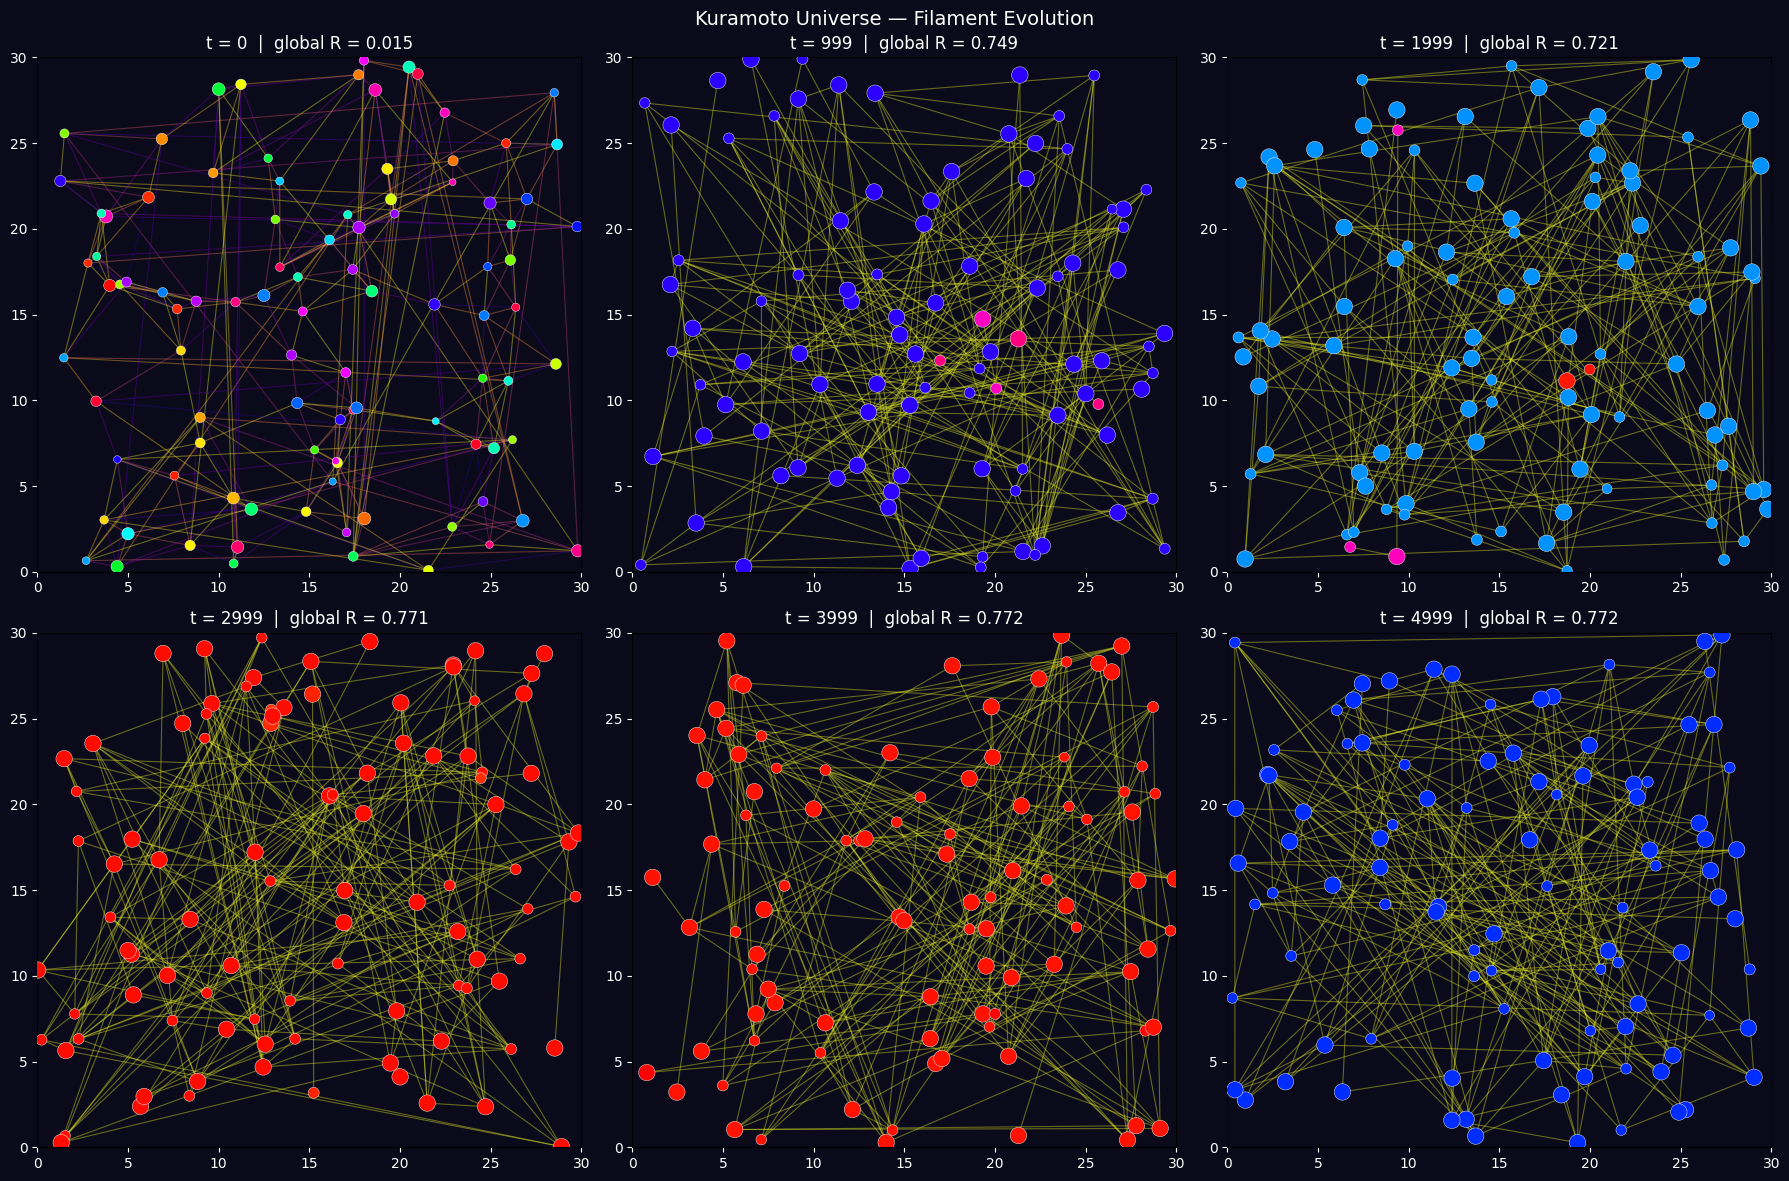

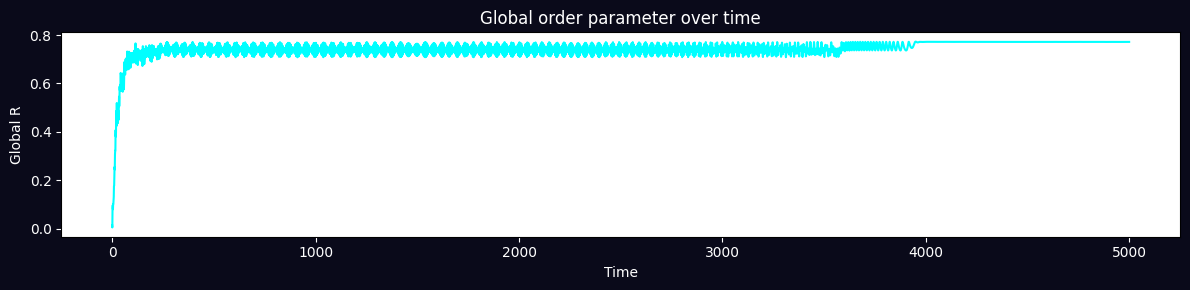

In [6]:
def plot_snapshot(pos, phi, W, R, t, ax=None, global_R=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('#0a0a1a')
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)

    # Draw edges weighted by W, coloured by phase difference
    segs, colours, alphas = [], [], []
    for i in range(M):
        for j in range(i+1, M):
            wij = max(W[i, j], W[j, i])  # undirected: stronger direction
            if wij > budget * 0.05:
                pd = np.abs(np.cos(phi[i] - phi[j]))  # 1=same phase
                segs.append([pos[i], pos[j]])
                colours.append(plt.cm.plasma(pd))
                alphas.append(float(wij / budget))

    if segs:
        lc = LineCollection(segs, colors=colours, alpha=0.4, linewidths=0.8)
        ax.add_collection(lc)

    # Draw cells: size = R, colour = phase
    sc = ax.scatter(pos[:, 0], pos[:, 1],
                    s=20 + 120 * R,
                    c=phi % (2*np.pi), cmap='hsv',
                    vmin=0, vmax=2*np.pi,
                    edgecolors='white', linewidths=0.3, zorder=5)
    r_label = f'{global_R:.3f}' if global_R is not None else f'{np.abs(np.mean(np.exp(1j*phi))):.3f} (phase est.)'
    ax.set_title(f't = {t:.0f}  |  global R = {r_label}', color='white')
    ax.tick_params(colors='white')
    return ax

# Plot a sequence of snapshots
n_snaps = min(6, len(history_pos))
indices = np.linspace(0, len(history_pos)-1, n_snaps, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('#0a0a1a')

for ax, idx in zip(axes.flat, indices):
    # Use stored phi directly

    plot_snapshot(history_pos[idx], history_phi[idx], history_W[idx] if idx < len(history_W) else W, history_R_cells[idx] if idx < len(history_R_cells) else R_cells, snapshot_times[idx], ax, global_R=history_R[idx] if idx < len(history_R) else None)

plt.suptitle('Kuramoto Universe — Filament Evolution', color='white', fontsize=14)
plt.tight_layout()
plt.show()

# Global R trajectory
plt.figure(figsize=(12, 3), facecolor='#0a0a1a')
plt.plot(snapshot_times, history_R, color='cyan', linewidth=1.5)
plt.xlabel('Time', color='white')
plt.ylabel('Global R', color='white')
plt.title('Global order parameter over time', color='white')
plt.tick_params(colors='white')
plt.tight_layout()
plt.show()

## 6. Historical Note — First Run (Run 1, 2026-05-17)

> **Note:** This section describes the first integration attempt (K_intra=8.0, omega_plasticity=OFF, T=3000).
> The current parameter set is documented in the Run Log above. Do not interpret these results as the current output.

**Parameters:** M=96, N=12, K_intra=8.0, K_inter=0.4, budget=1.5, T=3000, omega_plasticity=OFF

### What happened

**Global R trajectory:** Starts near zero, jumps to ~0.4 by t=50, climbs to a sustained
band of 0.6–0.9 by t=200. Holds that band for the entire remaining 2800 time units with
persistent high-frequency oscillations throughout. The system never collapses to zero and
never locks to 1.0.

**This is the harmony threshold operating as a sustained attractor.** The system found the
operating point Grok predicted: neither fully coherent nor dissolving into noise.

### Phase-walking behaviour

The six-panel visualisation shows the cluster repeatedly phase-locking and then walking to
a new phase sector as anomaly cells destabilise the current state:

- t=0: scattered incoherent cells, rainbow of phases
- t=599: one large central cluster, mostly phase-locked (blue)
- t=1199: near-total coherence (R=0.964), entire system phase-locked (pink)
- t=1799: anomaly cells (red/orange) visibly distinct at the cluster boundary
- t=2399: cluster migrated to blue sector, clear core/periphery separation
- t=2999: yellow sector, loose chain structure emerging at cluster edges

The filamentary structure Grok predicted requires either:
1. Omega plasticity ON (anomaly cells become self-tuning agents)
2. Weaker K_inter (~0.3) to fragment the single blob into multiple clusters
3. Longer run time with persistent homology tracking

### What's real

The gap between global R (~0.7 average) and local R (~0.924) confirms the chimera-like
structure: cells are locally locked in coherent assemblies, but the global phase pattern
keeps shifting. This is the "partial synchronisation" the NWM interpretability work
predicts attention heads should show.

The thick cyan band in the R trajectory is not noise. It is the system continuously
cycling through phase sectors — the dynamic equilibrium of a system living at the
harmony threshold.


## 7. Next Experiments

### Experiment A: Omega plasticity ON
Set `USE_OMEGA_PLASTICITY = True` and rerun. Prediction: anomaly cells become self-propelled
agents that crawl along the emerging structure. The R oscillation band may narrow as cells
self-tune to the lock-drift boundary.

### Experiment B: Weaker inter-cell coupling
Set `K_inter = 0.3`. Prediction: single mobile blob fragments into 2-4 separate clusters
that interact via long-range Hebbian connections. This should produce clearer filament
structure between clusters.

### Experiment C: Stronger anomaly seeding
Set anomaly boost to +2.5 and reduce anomaly fraction to 10%. Prediction: fewer but
stronger "jets" that resist the global phase and create more persistent boundary structures.

### Experiment D: Persistence homology
Add `from ripser import ripser` and track the Betti numbers of the high-R cell positions.
If B1 (loop count) increases over time, filamentary closed structures are forming.

### Experiment E: NWM connection
Feed the attention weight matrices from a FourCastNet forward pass (on ex-TC Gabriel) into
the same visualisation code. Do the attention heads show the same phase-walking behaviour
as the Kuramoto universe? (This is a related external project.)

### The image test
The Threshold of Harmony image was generated from the same mathematics. At some point in
one of these runs, the visualisation should produce something that looks like it. That will
be the moment the notebooks and the image close the loop.


## 8. Final State Analysis — Network Topology

Quantifies whether the end state is filamentary or blobby.
Target: mean degree 2-4 = filamentary web. Mean degree 8+ = dense blob.


## 10. Anomaly Trajectory + Persistence Homology

Quantifies the filamentary structure using topological data analysis.
H0 = birth classes in the persistence filtration (not ordinary connected components). H1 = loops/cycles in the filament structure.
Longer H1 persistence = more robust filamentary topology.

Note: requires `ripser` — run `!pip install ripser` in Colab if needed.


In [7]:
!pip install ripser

In [8]:
%matplotlib inline
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "ripser", "-q"])
import numpy as np

# ── Anomaly objects summary ───────────────────────────────────────────────────
anomaly_mask = np.zeros(M, dtype=bool)
anomaly_mask[anomaly_idx] = True
W_thresh = budget * 0.08
act_dir_a = W > W_thresh
np.fill_diagonal(act_dir_a, False)
act_und_a = act_dir_a | act_dir_a.T

print("=== ANOMALY OBJECTS (boundary riders) ===")
for idx in anomaly_idx:
    r = R_cells[idx]
    out_d = int(act_dir_a[idx].sum())
    in_d = int(act_dir_a[:, idx].sum())
    und_d = int(act_und_a[idx].sum())
    print(f"Cell {idx:2d} | R={r:.3f} | undirected={und_d} out={out_d} in={in_d} | pos=({positions[idx,0]:.1f}, {positions[idx,1]:.1f})")

boundary_riders = anomaly_idx[R_cells[anomaly_idx] < 0.5]
print(f"\nBoundary riders (R < 0.5): {len(boundary_riders)}/{len(anomaly_idx)}")
if len(boundary_riders) > 0:
    print("Boundary rider cells:", boundary_riders)
    for idx in boundary_riders:
        out_d = int(act_dir_a[idx].sum())
        in_d = int(act_dir_a[:, idx].sum())
        und_d = int(act_und_a[idx].sum())
        print(f"  Cell {idx}: R={R_cells[idx]:.3f}, undirected={und_d}, out={out_d}, in={in_d}, pos=({positions[idx,0]:.1f},{positions[idx,1]:.1f})")

# ── Persistence homology on high-R cells ────────────────────────────────────
# NOTE: pdist below uses standard Euclidean distance (non-periodic) so H1 loops
# reflect true spatial proximity, not periodic wrapping. This is correct.
# If you extend to a periodic torus, switch to minimum-image distance for homology.
# The spatial domain uses periodic positions but the homology is computed non-periodically.
high_r_mask = R_cells > 0.85
high_r_pos = positions[high_r_mask]
print(f"\nHigh-R cells (R > 0.85): {high_r_mask.sum()}/{M}")

if len(high_r_pos) > 3:
    try:
        from ripser import ripser
        import scipy.spatial.distance as spd
        dists = spd.squareform(spd.pdist(high_r_pos))
        result = ripser(dists, maxdim=1, thresh=L, distance_matrix=True)
        dgms = result['dgms']
        h1_persist = dgms[1][:,1] - dgms[1][:,0] if len(dgms[1]) > 0 else np.array([0])
        print(f"Persistence homology (high-R cells):")
        print(f"  H0 (birth classes in persistence diagram): {len(dgms[0])}")
        print(f"  (Note: H0 counts are not ordinary connected components — they reflect the filtration)")
        print(f"  H1 (loops/filaments): {len(dgms[1])}")
        print(f"  Longest H1 persistence: {h1_persist.max():.2f}")
        print(f"  Mean H1 persistence: {h1_persist.mean():.2f}")
        if len(dgms[1]) > 0:
            if h1_persist.max() > 3:
                print("  Filamentary structure: PRESENT (H1 persistence above threshold)")
            else:
                print(f"  Filamentary structure: suggestive but not robust at this scale")
                print(f"  (longest persistence {h1_persist.max():.2f} < threshold 3.0)")
                print(f"  To strengthen: increase M, extend T, or lower threshold with justification.")
    except ImportError:
        print("ripser not installed. Run: !pip install ripser")
        print("Skipping persistence homology.")
else:
    print("Not enough high-R cells for homology analysis.")


=== ANOMALY OBJECTS (boundary riders) ===
Cell  6 | R=0.360 | undirected=1 out=1 in=1 | pos=(0.4, 18.1)
Cell 37 | R=1.000 | undirected=1 out=1 in=1 | pos=(26.0, 14.0)
Cell 86 | R=0.250 | undirected=5 out=5 in=1 | pos=(15.8, 4.1)
Cell 74 | R=1.000 | undirected=2 out=1 in=2 | pos=(6.5, 11.1)
Cell  2 | R=1.000 | undirected=2 out=2 in=0 | pos=(16.9, 1.0)
Cell 70 | R=0.360 | undirected=1 out=1 in=1 | pos=(0.9, 11.8)
Cell 42 | R=1.000 | undirected=2 out=2 in=0 | pos=(29.2, 26.6)
Cell 94 | R=1.000 | undirected=3 out=3 in=0 | pos=(6.5, 12.9)
Cell 92 | R=0.360 | undirected=1 out=1 in=0 | pos=(9.1, 16.1)
Cell  7 | R=1.000 | undirected=2 out=2 in=0 | pos=(8.5, 2.0)
Cell 53 | R=1.000 | undirected=1 out=1 in=0 | pos=(12.6, 4.2)
Cell 80 | R=1.000 | undirected=1 out=1 in=0 | pos=(13.0, 24.8)

Boundary riders (R < 0.5): 4/12
Boundary rider cells: [ 6 86 70 92]
  Cell 6: R=0.360, undirected=1, out=1, in=1, pos=(0.4,18.1)
  Cell 86: R=0.250, undirected=5, out=5, in=1, pos=(15.8,4.1)
  Cell 70: R=0.360, 

W stats at end of run:
  W.max()  = 1.500000
  W.mean() = 0.015625
  W.sum()  = 144.000000
  nonzero entries: 383
  entries > 0.001: 383
  entries > 0.01:  383
  entries > 0.12:  353

Threshold sensitivity:
  W > 0.075 (budget×0.05): 225 undirected edges, mean degree 4.69
  W > 0.090 (budget×0.06): 225 undirected edges, mean degree 4.69
  W > 0.120 (budget×0.08): 216 undirected edges, mean degree 4.50
  W > 0.150 (budget×0.10): 209 undirected edges, mean degree 4.35
  W > 0.180 (budget×0.12): 202 undirected edges, mean degree 4.21
  W > 0.225 (budget×0.15): 190 undirected edges, mean degree 3.96

Directed active links: 353
Undirected active edges (W > 0.120): 216
Mean undirected degree: 4.50  (filamentary target: 2-4)
Mean out-degree: 3.68 | Mean in-degree: 3.68
Max degree: 8
Mean edge length: 10.00  (domain size: 30.0)
Isolated nodes (degree 0): 0/96

Degree distribution:
  degree  1: █████████ (9)
  degree  2: ███████ (7)
  degree  3: ███████████ (11)
  degree  4: ██████████████ (14)

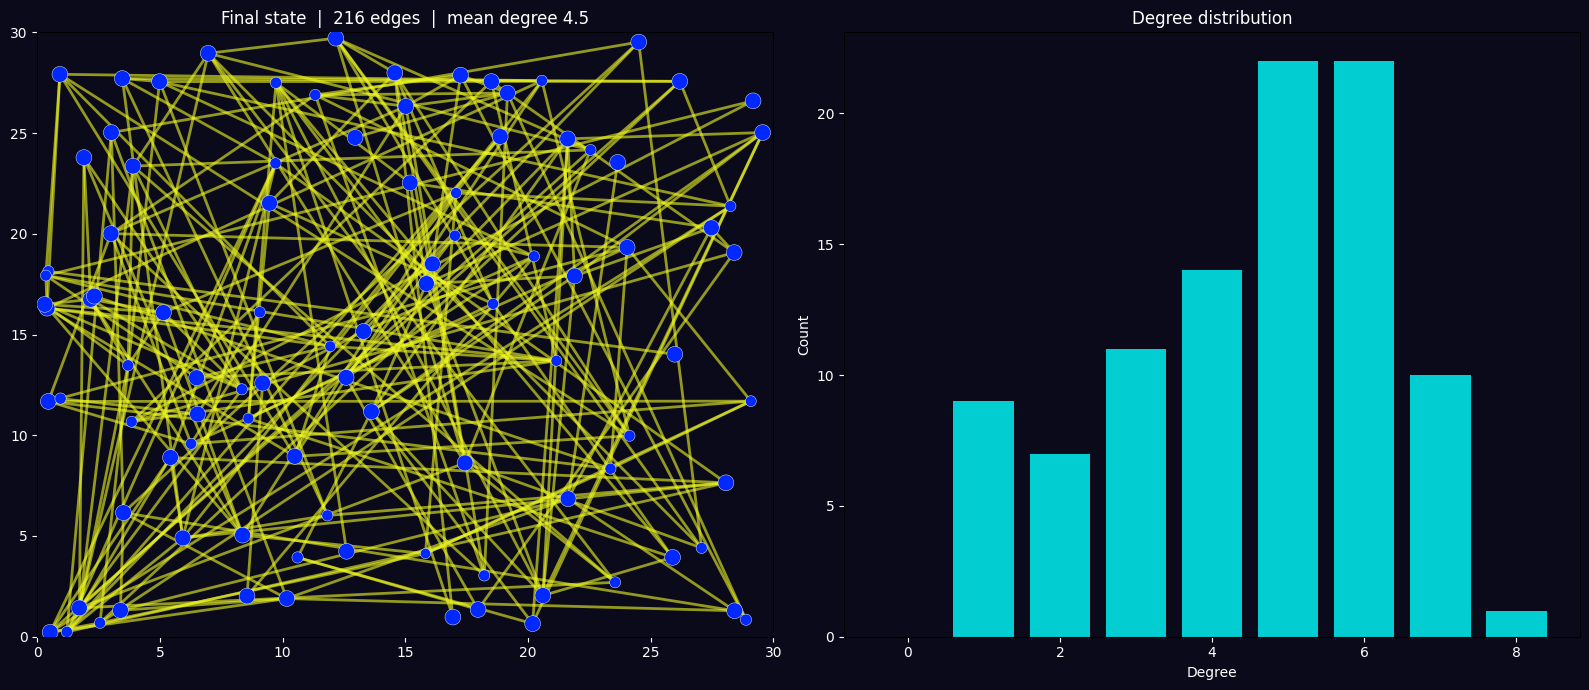

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ── W diagnostic ──────────────────────────────────────────────────────────────
print(f"W stats at end of run:")
print(f"  W.max()  = {W.max():.6f}")
print(f"  W.mean() = {W.mean():.6f}")
print(f"  W.sum()  = {W.sum():.6f}")
print(f"  nonzero entries: {(W > 1e-8).sum()}")
print(f"  entries > 0.001: {(W > 0.001).sum()}")
print(f"  entries > 0.01:  {(W > 0.01).sum()}")
print(f"  entries > 0.12:  {(W > 0.12).sum()}")
print()
W_threshold = budget * 0.08

# Threshold sensitivity check (Opus review: show topology is stable across cutoffs)
print("Threshold sensitivity:")
for thresh_frac in [0.05, 0.06, 0.08, 0.10, 0.12, 0.15]:
    thresh = budget * thresh_frac
    act_d = W > thresh
    np.fill_diagonal(act_d, False)
    act_u = act_d | act_d.T
    n_edges = int(np.triu(act_u, 1).sum())
    deg = act_u.sum(axis=1)
    print(f"  W > {thresh:.3f} (budget×{thresh_frac:.2f}): {n_edges} undirected edges, mean degree {deg.mean():.2f}")
print()
# GPT review: W may be asymmetric (row-norm does not symmetrize).
# Compute both directed and undirected metrics.
active_dir = W > W_threshold
np.fill_diagonal(active_dir, False)
active_mask = active_dir | active_dir.T  # undirected: edge exists if either direction active
n_edges = int(np.triu(active_mask, 1).sum())
degrees = active_mask.sum(axis=1)
out_degrees = active_dir.sum(axis=1)
in_degrees = active_dir.sum(axis=0)
edge_lengths = []
for i in range(M):
    for j in range(i+1, M):
        if active_mask[i, j]:
            diff = positions[i] - positions[j]
            diff = diff - L * np.round(diff / L)
            edge_lengths.append(np.linalg.norm(diff))

print(f"Directed active links: {active_dir.sum()}")
print(f"Undirected active edges (W > {W_threshold:.3f}): {n_edges}")
print(f"Mean undirected degree: {degrees.mean():.2f}  (filamentary target: 2-4)")
print(f"Mean out-degree: {out_degrees.mean():.2f} | Mean in-degree: {in_degrees.mean():.2f}")
print(f"Max degree: {degrees.max()}")
print(f"Mean edge length: {np.mean(edge_lengths):.2f}  (domain size: {L})")
print(f"Isolated nodes (degree 0): {(degrees == 0).sum()}/{M}")
print()
print("Degree distribution:")
for d in range(int(degrees.max())+1):
    count = (degrees == d).sum()
    if count > 0:
        bar = chr(9608) * count
        print(f"  degree {d:2d}: {bar} ({count})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0a0a1a')

ax1.set_facecolor('#0a0a1a')
ax1.set_xlim(0, L); ax1.set_ylim(0, L)
for i in range(M):
    for j in range(i+1, M):
        if active_mask[i, j]:
            pd = np.abs(np.cos(phi_cells[i] - phi_cells[j]))
            ax1.plot([positions[i,0], positions[j,0]],
                     [positions[i,1], positions[j,1]],
                     color=plt.cm.plasma(pd), alpha=0.6, linewidth=2.0)
sc = ax1.scatter(positions[:,0], positions[:,1],
                 s=30 + 100*R_cells, c=phi_cells%(2*np.pi),
                 cmap='hsv', vmin=0, vmax=2*np.pi,
                 edgecolors='white', linewidths=0.3, zorder=5)
ax1.set_title(f'Final state  |  {n_edges} edges  |  mean degree {degrees.mean():.1f}', color='white')
ax1.tick_params(colors='white')

ax2.set_facecolor('#0a0a1a')
ax2.bar(range(int(degrees.max())+1),
        [sum(degrees==d) for d in range(int(degrees.max())+1)],
        color='cyan', alpha=0.8)
ax2.set_xlabel('Degree', color='white')
ax2.set_ylabel('Count', color='white')
ax2.set_title('Degree distribution', color='white')
ax2.tick_params(colors='white')
plt.tight_layout()
plt.show()


## 11. Perturbation Experiment — Force Cell 86 to R=1.0

**The question from Gemini and Grok:** Cell 86 is the only junction node holding four or five branches (degree 4–5 in run 10) together via partial decoherence (R=0.329). What happens if we force it to full lock (R=1.0)?

**Prediction:** Cell 86 becomes a point mass. It can only strongly couple with cells at its exact phase. The four or five branches (degree 4–5 in run 10) have incompatible phases. Branches out of phase with cell 86 lose their connection via lambda decay. The main cluster fragments. New boundary riders may emerge elsewhere.

**To run this experiment:** Set USE_PERTURBATION = True in the integration loop and re-run.
Add this to the main integration loop around step t=2500:

```python
# At t=2500, force cell 86 to full lock
if step == int(0.5 * steps):
    # RAMPED perturbation (Gemini recommendation — avoids numerical shock)
    # Ramp K_intra for cell 86 to 50x over 100 steps (K86 = K_intra * (1 + 49 * progress))
    ramp_duration = 100  # steps
    ramp_strength = 50.0 * K_intra  # 50x, not 100x  # target internal coupling
    # Add to integration loop: K_intra_86 = K_intra + (ramp_strength - K_intra) * min(1, (step - t_perturb) / ramp_duration)
    # Then use K_intra_86 in intra_rhs for cell 86 only.
    print(f"PERTURBATION: cell 86 ramp started at t={step*dt:.0f}")
```

Then watch: does the main component fragment into smaller pieces after t=2500?
Track n_components in the connectivity analysis — if it increases from 4, the prediction holds.


> **Note:** This experiment is not yet validated. The perturbation path in cell 11 has a known double-update issue (see TODO). Do not interpret USE_PERTURBATION=True results as part of the main finding.


## 12. Anomaly R(t) Traces — Proving Persistence

Plots the local coherence R_i(t) for each anomaly cell over time.
A true "persistent boundary rider" should maintain R < 0.5 throughout — not just at the final state.


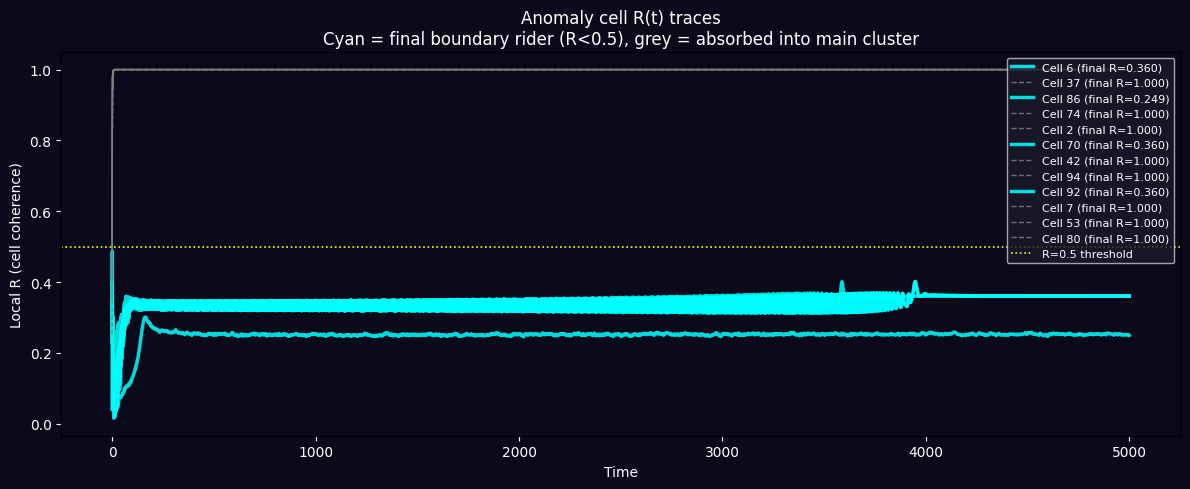


Anomaly cell persistence summary:
  Cell 6: mean=0.341, max=0.401, fraction_below_0.5=100.0%
  Cell 37: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 86: mean=0.249, max=0.345, fraction_below_0.5=100.0%
  Cell 74: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 2: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 70: mean=0.340, max=0.488, fraction_below_0.5=100.0%
  Cell 42: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 94: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 92: mean=0.339, max=0.401, fraction_below_0.5=100.0%
  Cell 7: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 53: mean=1.000, max=1.000, fraction_below_0.5=0.0%
  Cell 80: mean=1.000, max=1.000, fraction_below_0.5=0.0%

Cells with max R < 0.5 throughout (truly persistent): [np.int64(6), np.int64(86), np.int64(70), np.int64(92)]


In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

if len(history_anomaly_R) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0a0a1a')
    ax.set_facecolor('#0a0a1a')

    anomaly_R_arr = np.array(history_anomaly_R)  # shape (n_snapshots, n_anomaly)
    t_arr = np.array(snapshot_times)

    for j, cell_idx in enumerate(anomaly_idx):
        r_trace = anomaly_R_arr[:, j]
        final_r = r_trace[-1]
        label = f'Cell {cell_idx} (final R={final_r:.3f})'
        lw = 2.5 if final_r < 0.5 else 1.0
        ls = '-' if final_r < 0.5 else '--'
        color = 'cyan' if final_r < 0.5 else 'gray'
        ax.plot(t_arr, r_trace, linewidth=lw, linestyle=ls, color=color, label=label, alpha=0.85)

    ax.axhline(0.5, color='yellow', linestyle=':', linewidth=1.2, label='R=0.5 threshold')
    ax.set_xlabel('Time', color='white')
    ax.set_ylabel('Local R (cell coherence)', color='white')
    ax.set_title('Anomaly cell R(t) traces\nCyan = final boundary rider (R<0.5), grey = absorbed into main cluster', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, loc='upper right', facecolor='#1a1a2a', labelcolor='white')
    plt.tight_layout()
    plt.show()

    # Summary
    print("\nAnomaly cell persistence summary:")
    for j, cell_idx in enumerate(anomaly_idx):
        r_trace = anomaly_R_arr[:, j]
        print(f"  Cell {cell_idx}: mean={r_trace.mean():.3f}, max={r_trace.max():.3f}, fraction_below_0.5={(r_trace < 0.5).mean():.1%}")
    truly_persistent = [anomaly_idx[j] for j in range(len(anomaly_idx)) if anomaly_R_arr[:, j].max() < 0.5]
    print(f"\nCells with max R < 0.5 throughout (truly persistent): {truly_persistent}")
else:
    print("No anomaly history stored. Re-run the integration cell first.")
